# Test Saved 100% Data-Amount Sweep Model On Ansys Validation Targets

This notebook checks whether the saved `100%` model from the training-data sweep carries over to the same Hamiltonian targets used for the Ansys validation boxplots.

Run `ml_32_corner_far_to_near.ipynb` first. That notebook saves every trained sweep model under `model/corner_far_to_near_data_amount_sweep_fixed_surrogate/`; this notebook loads the `fraction_100pct_seed*_combined.keras` models from that folder and evaluates them on the Ansys target set.

The comparison is surrogate-only for the saved inverse+surrogate model. The Ansys boxplot rows still come from the existing Ansys re-simulation JSON.


In [10]:
from __future__ import annotations

import ast
import gc
import json
import os
import sys
import zipfile
from dataclasses import dataclass
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Input, LeakyReLU
from tensorflow.keras.models import load_model

try:
    tf.keras.backend.set_floatx("float32")
except Exception:
    pass

print("TensorFlow", tf.__version__)


TensorFlow 2.20.0


In [11]:
# Paths and run controls

HERE = Path.cwd()
EXPERIMENT_RELATIVE = Path("experiments/model_predict_qubit_TransmonCross_Hamiltonian_params")

if (HERE / "metadata" / "qubit-TransmonCross-Hamiltonian_params.json").exists():
    EXPERIMENT_DIR = HERE
elif (HERE / EXPERIMENT_RELATIVE / "metadata" / "qubit-TransmonCross-Hamiltonian_params.json").exists():
    EXPERIMENT_DIR = HERE / EXPERIMENT_RELATIVE
else:
    raise FileNotFoundError(
        "Could not find the transmon metadata file. Run from the repo root or the transmon experiment folder."
    )

if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIR))

from parameters_surrogate_defined_loss import (  # noqa: E402
    EPOCHS,
    MODEL_DIR as PARAM_MODEL_DIR,
    SCALERS_DIR as PARAM_SCALERS_DIR,
    TRAIN_BATCH_SIZE,
    TRAIN_EARLY_STOPPING_PATIENCE,
    TRAIN_LOSS,
)

METADATA_DIR = EXPERIMENT_DIR / "metadata"
METADATA_PATH = METADATA_DIR / "qubit-TransmonCross-Hamiltonian_params.json"
RESULTS_DIR = EXPERIMENT_DIR / "results"
VALIDATION_DIR = RESULTS_DIR / "validation"
OUTPUT_DIR = VALIDATION_DIR / "data_amount_100pct_on_ansys_targets"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_DIR = Path(PARAM_MODEL_DIR)
SCALERS_DIR = Path(PARAM_SCALERS_DIR)

SURROGATE_MODEL_PATH = MODEL_DIR / "best_keras_model_model2_surrogate.keras"
SWEEP_MODEL_DIR = MODEL_DIR / "corner_far_to_near_data_amount_sweep_fixed_surrogate"
REFERENCE_COMBINED_MODEL_CANDIDATES = [
    MODEL_DIR / "surrogate_loss_2in_3out_best_model.keras",
    MODEL_DIR / "best_keras_model_surrogate_defined_loss.keras",
]
REFERENCE_COMBINED_MODEL_PATH = next((p for p in REFERENCE_COMBINED_MODEL_CANDIDATES if p.exists()), None)
if REFERENCE_COMBINED_MODEL_PATH is None:
    raise FileNotFoundError("No reference combined inverse+surrogate model found in MODEL_DIR")

ANSYS_TARGETS_PATH = VALIDATION_DIR / "Hamiltonian-based-inverse+surrogate_MLP_results.csv"
ANSYS_RESULTS_JSON_PATH = VALIDATION_DIR / "final_inverse+surrogate_ansys_results.json"
REPORTED_SWEEP_CSV = EXPERIMENT_DIR / "data_amount_sweep_far_to_near.csv"
CORNER_SWEEP_CSV = EXPERIMENT_DIR / "data_amount_sweep_corner_far_to_near_fixed_surrogate.csv"

# The sweep notebook saves one model per seed. Use one seed for a quick first pass,
# or all three to reproduce the plotted mean-over-seeds convention.
SEEDS_TO_RUN = (0, 1, 2)
REQUIRE_SAVED_100PCT_SWEEP_MODEL = True

print("Experiment:", EXPERIMENT_DIR)
print("Surrogate:", SURROGATE_MODEL_PATH)
print("Reference combined model:", REFERENCE_COMBINED_MODEL_PATH)
print("Saved sweep model dir:", SWEEP_MODEL_DIR)
print("Ansys target CSV:", ANSYS_TARGETS_PATH)
print("Ansys result JSON:", ANSYS_RESULTS_JSON_PATH)
print("Output dir:", OUTPUT_DIR)


Experiment: /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params
Surrogate: /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/model/best_keras_model_model2_surrogate.keras
Reference combined model: /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/model/surrogate_loss_2in_3out_best_model.keras
Saved sweep model dir: /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/model/corner_far_to_near_data_amount_sweep_fixed_surrogate
Ansys target CSV: /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/results/validation/Hamiltonian-based-inverse+surrogate_MLP_results.csv
Ansys result JSON: /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/results/validation/final_inverse+surrogate_ansys_results.json
Output dir: /home/olivias/ML_qubit_d

In [12]:
# Data loading, split recreation, and scaler helpers

EPS = 1e-12
HAMILTONIAN_COLUMN_NAMES = ["qubit_frequency_GHz", "anharmonicity_MHz"]
QISKIT_PARAM_NAMES = [
    "design_options.connection_pads.readout.claw_length",
    "design_options.connection_pads.readout.ground_spacing",
    "design_options.cross_length",
]

@dataclass
class SimpleMinMaxScaler:
    min_: np.ndarray
    max_: np.ndarray

    @property
    def range_(self) -> np.ndarray:
        return np.maximum(self.max_ - self.min_, EPS)

    def transform(self, x: np.ndarray) -> np.ndarray:
        return (np.asarray(x, dtype=np.float64) - self.min_) / self.range_

    def inverse_transform(self, x: np.ndarray) -> np.ndarray:
        return np.asarray(x, dtype=np.float64) * self.range_ + self.min_


def parse_um(value: object) -> float:
    text = str(value).strip()
    for suffix in ("um", "µm", "μm"):
        if text.endswith(suffix):
            return float(text[: -len(suffix)])
    return float(text)


def load_metadata_arrays() -> tuple[np.ndarray, np.ndarray]:
    rows = json.loads(METADATA_PATH.read_text())
    hamiltonian = []
    geometry_um = []
    for row in rows:
        h = row["Hamiltonian_params"]
        opts = row["design"]["design_options"]
        readout = opts["connection_pads"]["readout"]
        hamiltonian.append([
            float(h["qubit_frequency_GHz"]),
            float(h["anharmonicity_MHz"]),
        ])
        geometry_um.append([
            parse_um(readout["claw_length"]),
            parse_um(readout["ground_spacing"]),
            parse_um(opts["cross_length"]),
        ])
    return np.asarray(hamiltonian, dtype=np.float64), np.asarray(geometry_um, dtype=np.float64)


def scaler_from_artifacts(values: np.ndarray, columns: list[str], path_patterns: list[str], label: str):
    mins, maxs, sources = [], [], []
    for i, col in enumerate(columns):
        loaded = None
        source = None
        for pattern in path_patterns:
            candidate = SCALERS_DIR / pattern.format(col=col)
            if candidate.exists():
                loaded = joblib.load(candidate)
                source = str(candidate)
                break
        if loaded is not None:
            mins.append(float(np.asarray(loaded.data_min_).reshape(-1)[0]))
            maxs.append(float(np.asarray(loaded.data_max_).reshape(-1)[0]))
            sources.append(source)
        else:
            mins.append(float(np.min(values[:, i])))
            maxs.append(float(np.max(values[:, i])))
            sources.append(f"metadata fallback: {label}.{col}")
    return SimpleMinMaxScaler(np.asarray(mins), np.asarray(maxs)), sources


h_raw, geom_raw_um = load_metadata_arrays()
geom_raw_si = geom_raw_um * 1e-6
all_idx = np.arange(len(h_raw))

# Recreate ml_00 split: 70% train, 15% validation, 15% test using random_state=42.
train_idx, val_test_idx = train_test_split(all_idx, test_size=0.3, random_state=42, shuffle=True)
val_idx, test_idx = train_test_split(val_test_idx, test_size=0.5, random_state=42, shuffle=True)

assert len(np.intersect1d(train_idx, val_idx)) == 0
assert len(np.intersect1d(train_idx, test_idx)) == 0
assert len(np.intersect1d(val_idx, test_idx)) == 0

h_model_scaler, h_scaler_sources = scaler_from_artifacts(
    h_raw,
    HAMILTONIAN_COLUMN_NAMES,
    ["scaler_X_{col}.save", "scaler_X_linear_{col}.save"],
    "Hamiltonian",
)
geom_inverse_scaler, geom_inverse_scaler_sources = scaler_from_artifacts(
    geom_raw_si,
    QISKIT_PARAM_NAMES,
    ["scaler_y_{col}_one_hot_encoding.save"],
    "inverse_qiskit",
)
geom_surrogate_scaler, geom_surrogate_scaler_sources = scaler_from_artifacts(
    geom_raw_si,
    QISKIT_PARAM_NAMES,
    ["scaler_y_linear_{col}.save", "scaler_y_{col}_one_hot_encoding.save"],
    "surrogate_qiskit",
)

h_model_scaled = h_model_scaler.transform(h_raw).astype("float32")
geom_inverse_scaled = geom_inverse_scaler.transform(geom_raw_si).astype("float32")
geom_surrogate_scaled = geom_surrogate_scaler.transform(geom_raw_si).astype("float32")

# Converts inverse-output scaler space into surrogate-input scaler space.
scale_a = (geom_inverse_scaler.range_ / geom_surrogate_scaler.range_).astype("float32")
scale_b = ((geom_inverse_scaler.min_ - geom_surrogate_scaler.min_) / geom_surrogate_scaler.range_).astype("float32")

print(f"Total metadata rows: {len(h_raw)}")
print(f"Train / val / test: {len(train_idx)} / {len(val_idx)} / {len(test_idx)}")
print("Expected 100% training-fraction n_samples:", len(train_idx))
print()
print("Scaler sources:")
all_scaler_sources = h_scaler_sources + geom_inverse_scaler_sources + geom_surrogate_scaler_sources
for name, source in zip(HAMILTONIAN_COLUMN_NAMES, h_scaler_sources):
    print(f"  H {name}: {source}")
for name, source in zip(QISKIT_PARAM_NAMES, geom_inverse_scaler_sources):
    print(f"  inverse geometry {name}: {source}")
for name, source in zip(QISKIT_PARAM_NAMES, geom_surrogate_scaler_sources):
    print(f"  surrogate geometry {name}: {source}")

if any(str(source).startswith("metadata fallback") for source in all_scaler_sources):
    print()
    print("WARNING: One or more saved scaler artifacts are missing, so this notebook is using metadata-derived fallback ranges.")
    print("That is adequate for wiring/path checks, but the definitive comparison should be run with the original scalers")
    print("from ml_00/ml_10 restored in SCALERS_DIR, because the frozen surrogate was trained in that scaled space.")


Total metadata rows: 1934
Train / val / test: 1353 / 290 / 291
Expected 100% training-fraction n_samples: 1353

Scaler sources:
  H qubit_frequency_GHz: /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/scalers/scaler_X_qubit_frequency_GHz.save
  H anharmonicity_MHz: /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/scalers/scaler_X_anharmonicity_MHz.save
  inverse geometry design_options.connection_pads.readout.claw_length: /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/scalers/scaler_y_design_options.connection_pads.readout.claw_length_one_hot_encoding.save
  inverse geometry design_options.connection_pads.readout.ground_spacing: /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/scalers/scaler_y_design_options.connection_pads.readout.ground_spacing_one_hot_encoding.save
  inverse geometry design_options.

In [13]:
# Load the 100 Hamiltonian targets used by the Ansys validation setup.
# These are the target/ref Hamiltonians for the samples that were sent to Ansys.

ansys_target_df = pd.read_csv(ANSYS_TARGETS_PATH)
ansys_target_h_raw = ansys_target_df[["ref_qubit_frequency_GHz", "ref_anharmonicity_MHz"]].to_numpy(dtype=np.float64)
ansys_target_h_scaled = h_model_scaler.transform(ansys_target_h_raw).astype("float32")
ansys_target_sample_ids = np.arange(len(ansys_target_df), dtype=int)

if ANSYS_RESULTS_JSON_PATH.exists():
    ansys_rows = json.loads(ANSYS_RESULTS_JSON_PATH.read_text())
    ansys_result_df = pd.DataFrame(
        {
            "Sample": [int(row["Sample"]) for row in ansys_rows],
            "ansys_pred_qubit_frequency_GHz": [float(row["pred_H_params"]["qubit_frequency_GHz"]) for row in ansys_rows],
            "ansys_pred_anharmonicity_MHz": [float(row["pred_H_params"]["anharmonicity_MHz"]) for row in ansys_rows],
            "ansys_ref_qubit_frequency_GHz": [float(row["ref_H_params"]["qubit_frequency_GHz"]) for row in ansys_rows],
            "ansys_ref_anharmonicity_MHz": [float(row["ref_H_params"]["anharmonicity_MHz"]) for row in ansys_rows],
            "ansys_frequency_pct_error": [float(row["percent_error_frequency"]) for row in ansys_rows],
            "ansys_anharmonicity_pct_error": [float(row["percent_error_anharmonicity"]) for row in ansys_rows],
        }
    )
else:
    ansys_result_df = pd.DataFrame()

print("Ansys target Hamiltonians:", ansys_target_h_raw.shape)
print("Successful Ansys simulations:", len(ansys_result_df))
ansys_target_df.head()


Ansys target Hamiltonians: (100, 2)
Successful Ansys simulations: 97


,ref_qubit_frequency_GHz,ref_anharmonicity_MHz,ref_connection_pads.readout.claw_length,ref_connection_pads.readout.ground_spacing,ref_cross_length,pred_qubit_frequency_GHz,pred_anharmonicity_MHz,pred_connection_pads.readout.claw_length,pred_connection_pads.readout.ground_spacing,pred_cross_length
0,4.115077,-150.84438,0.00018,0.000005,0.00026,4.110201,-151.17564,0.000093,0.000004,0.000269
1,3.959486,-138.74413,0.00010,0.000010,0.00029,3.958715,-138.94519,0.000091,0.000005,0.000287
2,5.047258,-236.38904,0.00011,0.000004,0.00018,5.030609,-235.46786,0.000115,0.000005,0.000180
3,4.585577,-191.13847,0.00013,0.000005,0.00021,4.583496,-191.34407,0.000105,0.000004,0.000217
4,5.263721,-259.67355,0.00009,0.000005,0.00016,5.260493,-261.26547,0.000114,0.000005,0.000165


In [14]:
# Reference-model extraction and model builders


def read_keras_config(path: Path) -> dict:
    with zipfile.ZipFile(path) as zf:
        return json.loads(zf.read("config.json"))


def extract_reference_specs(combined_path: Path) -> tuple[dict, dict]:
    cfg = read_keras_config(combined_path)
    if cfg.get("class_name") == "Sequential" and cfg.get("config", {}).get("name") == "inverse_model":
        raise ValueError(
            f"{combined_path} appears to be the inverse-only model. Use the combined inverse+surrogate model."
        )
    layers = cfg["config"].get("layers", [])
    inverse_layer = next(
        layer for layer in layers
        if layer.get("class_name") == "Sequential" and layer.get("config", {}).get("name") == "inverse_model"
    )
    compile_cfg = cfg.get("compile_config") or {}
    return inverse_layer["config"], compile_cfg


def _initializer_from_config(config: dict | None, seed: int | None):
    if not config:
        return None
    cfg = json.loads(json.dumps(config))
    if seed is not None and isinstance(cfg.get("config"), dict) and "seed" in cfg["config"]:
        cfg["config"]["seed"] = seed
    try:
        return tf.keras.initializers.deserialize(cfg)
    except Exception:
        class_name = cfg.get("class_name")
        if class_name == "HeNormal":
            return tf.keras.initializers.HeNormal(seed=cfg.get("config", {}).get("seed"))
        if class_name == "LecunUniform":
            return tf.keras.initializers.LecunUniform(seed=cfg.get("config", {}).get("seed"))
        if class_name == "Zeros":
            return tf.keras.initializers.Zeros()
        return tf.keras.initializers.get(class_name)


def _regularizer_from_config(config: dict | None):
    if not config:
        return None
    try:
        return tf.keras.regularizers.deserialize(config)
    except Exception:
        if config.get("class_name") == "L2":
            return tf.keras.regularizers.l2(config.get("config", {}).get("l2", 0.01))
        raise


class ScalerConversionLayer(tf.keras.layers.Layer):
    def __init__(self, scale_a, scale_b, **kwargs):
        kwargs.setdefault("trainable", False)
        super().__init__(**kwargs)
        self._scale_a = tf.constant(scale_a, dtype=tf.float32)
        self._scale_b = tf.constant(scale_b, dtype=tf.float32)
        self._cfg = {
            "scale_a": list(np.asarray(scale_a, dtype=float)),
            "scale_b": list(np.asarray(scale_b, dtype=float)),
        }

    def call(self, inputs):
        a = tf.cast(self._scale_a, inputs.dtype)
        b = tf.cast(self._scale_b, inputs.dtype)
        return inputs * a + b

    def get_config(self):
        config = super().get_config()
        config.update(self._cfg)
        return config


def qiskit_range_penalty(y_true_dummy, y_pred):
    below = tf.nn.relu(-y_pred)
    above = tf.nn.relu(y_pred - 1.0)
    return tf.reduce_mean(below ** 2 + above ** 2)


def build_inverse_from_reference(input_dim: int, seed: int) -> Sequential:
    tf.keras.utils.set_random_seed(seed)
    model = Sequential(name=REFERENCE_INVERSE_CONFIG.get("name", "inverse_model"))
    for layer_idx, layer_cfg in enumerate(REFERENCE_INVERSE_CONFIG["layers"]):
        class_name = layer_cfg["class_name"]
        cfg = layer_cfg["config"]
        if class_name == "InputLayer":
            model.add(Input(shape=(input_dim,), name=cfg.get("name", "Hamiltonian_input")))
        elif class_name == "Dense":
            model.add(
                Dense(
                    cfg["units"],
                    activation=cfg.get("activation", "linear"),
                    name=cfg.get("name"),
                    kernel_initializer=_initializer_from_config(cfg.get("kernel_initializer"), seed + layer_idx),
                    bias_initializer=_initializer_from_config(cfg.get("bias_initializer"), None),
                    kernel_regularizer=_regularizer_from_config(cfg.get("kernel_regularizer")),
                    bias_regularizer=_regularizer_from_config(cfg.get("bias_regularizer")),
                )
            )
        elif class_name == "LeakyReLU":
            model.add(LeakyReLU(negative_slope=cfg.get("negative_slope", 0.01), name=cfg.get("name")))
        elif class_name == "Dropout":
            model.add(Dropout(rate=cfg.get("rate", 0.0), name=cfg.get("name")))
        else:
            raise ValueError(f"Unsupported reference layer type: {class_name}")
    return model


def deserialize_loss_name(loss_spec):
    if isinstance(loss_spec, str):
        return loss_spec
    if isinstance(loss_spec, dict) and loss_spec.get("config") == "qiskit_range_penalty":
        return qiskit_range_penalty
    return loss_spec


def build_reference_optimizer():
    return tf.keras.optimizers.deserialize(REFERENCE_COMPILE_CONFIG["optimizer"])


def load_frozen_surrogate():
    surrogate_model = load_model(SURROGATE_MODEL_PATH, compile=False)
    surrogate_model.trainable = False
    for layer in surrogate_model.layers:
        layer.trainable = False
    return surrogate_model


def build_combined_model(seed: int) -> tuple[Sequential, Model]:
    tf.keras.backend.clear_session()
    surrogate_model = load_frozen_surrogate()
    inverse_model = build_inverse_from_reference(h_model_scaled.shape[1], seed=seed)

    combined_input = Input(shape=(h_model_scaled.shape[1],), name="combined_input")
    predicted_qiskit = inverse_model(combined_input)
    predicted_qiskit_converted = ScalerConversionLayer(scale_a, scale_b, name="scaler_conversion")(predicted_qiskit)
    reconstructed_hamiltonian = surrogate_model(predicted_qiskit_converted)
    combined_model = Model(
        inputs=combined_input,
        outputs=[reconstructed_hamiltonian, predicted_qiskit],
        name="combined_model",
    )

    loss_spec = REFERENCE_COMPILE_CONFIG.get("loss", [TRAIN_LOSS, qiskit_range_penalty])
    if not isinstance(loss_spec, list):
        loss_spec = [TRAIN_LOSS, qiskit_range_penalty]
    loss = [deserialize_loss_name(loss_spec[0]), qiskit_range_penalty]
    loss_weights = [float(v) for v in REFERENCE_COMPILE_CONFIG.get("loss_weights", [1.0, 1.0])]
    jit_compile = bool(REFERENCE_COMPILE_CONFIG.get("jit_compile", False)) and not DISABLE_JIT_COMPILE

    combined_model.compile(
        optimizer=build_reference_optimizer(),
        loss=loss,
        loss_weights=loss_weights,
        jit_compile=jit_compile,
    )
    return inverse_model, combined_model


REFERENCE_INVERSE_CONFIG, REFERENCE_COMPILE_CONFIG = extract_reference_specs(REFERENCE_COMBINED_MODEL_PATH)
reference_dense_layers = [
    layer["config"].get("units")
    for layer in REFERENCE_INVERSE_CONFIG["layers"]
    if layer["class_name"] == "Dense"
]

print("Reference inverse Dense units, including output layer:", reference_dense_layers)
print("Reference optimizer:", REFERENCE_COMPILE_CONFIG.get("optimizer", {}).get("class_name"))
print("Reference optimizer config:", REFERENCE_COMPILE_CONFIG.get("optimizer", {}).get("config"))
print("Reference loss:", REFERENCE_COMPILE_CONFIG.get("loss"))
print("Reference loss weights:", REFERENCE_COMPILE_CONFIG.get("loss_weights"))
print("Reference jit_compile:", REFERENCE_COMPILE_CONFIG.get("jit_compile"))


Reference inverse Dense units, including output layer: [64, 3]
Reference optimizer: Adam
Reference optimizer config: {'name': 'adam', 'learning_rate': {'module': 'keras.optimizers.schedules', 'class_name': 'ExponentialDecay', 'config': {'initial_learning_rate': 0.001, 'decay_steps': 220, 'decay_rate': 0.99, 'staircase': False, 'name': 'ExponentialDecay'}, 'registered_name': None}, 'weight_decay': None, 'clipnorm': None, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'loss_scale_factor': None, 'gradient_accumulation_steps': None, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': False}
Reference loss: ['mae', {'module': 'builtins', 'class_name': 'function', 'config': 'qiskit_range_penalty', 'registered_name': 'function'}]
Reference loss weights: [1.0, 1]
Reference jit_compile: True


In [15]:
# Training, loading, evaluation, and saving helpers

CUSTOM_OBJECTS = {
    "ScalerConversionLayer": ScalerConversionLayer,
    "qiskit_range_penalty": qiskit_range_penalty,
}


def saved_sweep_model_paths_for_seed(seed: int, fraction: float = 1.0) -> tuple[Path, Path]:
    pct = int(round(fraction * 100))
    stem = f"fraction_{pct:03d}pct_seed{seed}"
    return (
        SWEEP_MODEL_DIR / f"{stem}_combined.keras",
        SWEEP_MODEL_DIR / f"{stem}_inverse.keras",
    )


def fit_or_load_100pct_model(seed: int) -> tuple[Model, Sequential | None, int | None]:
    combined_path, inverse_path = saved_sweep_model_paths_for_seed(seed, fraction=1.0)
    if combined_path.exists():
        print(f"Loading saved 100% sweep model for seed {seed}: {combined_path}")
        combined_model = load_model(combined_path, compile=False, custom_objects=CUSTOM_OBJECTS)
        return combined_model, None, None

    message = (
        f"Missing saved 100% sweep model for seed {seed}: {combined_path}. "
        "Run ml_32_corner_far_to_near.ipynb first so it saves the sweep models."
    )
    if REQUIRE_SAVED_100PCT_SWEEP_MODEL:
        raise FileNotFoundError(message)
    raise FileNotFoundError(message)


def saved_combined_model_path_for_seed(seed: int) -> str:
    return str(saved_sweep_model_paths_for_seed(seed, fraction=1.0)[0])

def get_inverse_model(combined_model: Model, inverse_model: Sequential | None = None):
    if inverse_model is not None:
        return inverse_model
    try:
        return combined_model.get_layer("inverse_model")
    except Exception:
        return None


def predict_hamiltonian_targets(combined_model: Model, h_scaled: np.ndarray):
    pred_h_scaled, pred_geom_inverse_scaled = combined_model.predict(np.asarray(h_scaled, dtype="float32"), verbose=0)
    pred_h_raw = h_model_scaler.inverse_transform(pred_h_scaled)
    pred_geom_si = geom_inverse_scaler.inverse_transform(pred_geom_inverse_scaled)
    return pred_h_raw, pred_geom_si, pred_geom_inverse_scaled


def percent_errors(pred_h_raw: np.ndarray, target_h_raw: np.ndarray) -> np.ndarray:
    return 100.0 * np.abs(pred_h_raw - target_h_raw) / np.maximum(np.abs(target_h_raw), EPS)


def evaluate_target_set(combined_model: Model, h_scaled: np.ndarray, h_target_raw: np.ndarray, sample_ids: np.ndarray, seed: int):
    pred_h_raw, pred_geom_si, pred_geom_scaled = predict_hamiltonian_targets(combined_model, h_scaled)
    pct = percent_errors(pred_h_raw, h_target_raw)
    out = pd.DataFrame(
        {
            "seed": seed,
            "Sample": sample_ids,
            "target_qubit_frequency_GHz": h_target_raw[:, 0],
            "target_anharmonicity_MHz": h_target_raw[:, 1],
            "surrogate_recon_qubit_frequency_GHz": pred_h_raw[:, 0],
            "surrogate_recon_anharmonicity_MHz": pred_h_raw[:, 1],
            "surrogate_frequency_pct_error": pct[:, 0],
            "surrogate_anharmonicity_pct_error": pct[:, 1],
            "pred_connection_pads.readout.claw_length": pred_geom_si[:, 0],
            "pred_connection_pads.readout.ground_spacing": pred_geom_si[:, 1],
            "pred_cross_length": pred_geom_si[:, 2],
            "pred_scaled_min": np.min(pred_geom_scaled, axis=1),
            "pred_scaled_max": np.max(pred_geom_scaled, axis=1),
        }
    )
    return out


ANSYS_INPUT_COLUMNS = [
    "ref_qubit_frequency_GHz",
    "ref_anharmonicity_MHz",
    "ref_connection_pads.readout.claw_length",
    "ref_connection_pads.readout.ground_spacing",
    "ref_cross_length",
    "pred_qubit_frequency_GHz",
    "pred_anharmonicity_MHz",
    "pred_connection_pads.readout.claw_length",
    "pred_connection_pads.readout.ground_spacing",
    "pred_cross_length",
]


def make_ansys_input_geometry_df(ansys_detail: pd.DataFrame, original_target_df: pd.DataFrame) -> pd.DataFrame:
    """Return the clean CSV format used for Ansys submission, with new model predictions only."""
    if len(ansys_detail) != len(original_target_df):
        raise ValueError(f"Row count mismatch: {len(ansys_detail)} predictions vs {len(original_target_df)} original targets")

    out = original_target_df[
        [
            "ref_qubit_frequency_GHz",
            "ref_anharmonicity_MHz",
            "ref_connection_pads.readout.claw_length",
            "ref_connection_pads.readout.ground_spacing",
            "ref_cross_length",
        ]
    ].copy()
    out["pred_qubit_frequency_GHz"] = ansys_detail["surrogate_recon_qubit_frequency_GHz"].to_numpy()
    out["pred_anharmonicity_MHz"] = ansys_detail["surrogate_recon_anharmonicity_MHz"].to_numpy()
    out["pred_connection_pads.readout.claw_length"] = ansys_detail["pred_connection_pads.readout.claw_length"].to_numpy()
    out["pred_connection_pads.readout.ground_spacing"] = ansys_detail["pred_connection_pads.readout.ground_spacing"].to_numpy()
    out["pred_cross_length"] = ansys_detail["pred_cross_length"].to_numpy()
    return out[ANSYS_INPUT_COLUMNS]


def summarize_errors(label: str, df: pd.DataFrame, freq_col: str, alpha_col: str) -> dict:
    return {
        "set": label,
        "n": int(len(df)),
        "frequency_mean_pct": float(df[freq_col].mean()),
        "frequency_median_pct": float(df[freq_col].median()),
        "alpha_mean_pct": float(df[alpha_col].mean()),
        "alpha_median_pct": float(df[alpha_col].median()),
        "mean_hamiltonian_pct": float(df[[freq_col, alpha_col]].to_numpy().mean()),
    }


In [16]:
# Load the saved 100% sweep models and evaluate them on:
# 1. The original fixed ml_00 test split, as a sanity check.
# 2. The 100 Ansys-validation target Hamiltonians.
# 3. The 97 samples where the Ansys simulation succeeded, joined by Sample id.

all_detail = []
summary_rows = []

if CORNER_SWEEP_CSV.exists():
    reported = pd.read_csv(CORNER_SWEEP_CSV)
    reported_100 = reported[reported["training_percent"].eq(100.0)]
    if not reported_100.empty:
        for _, row in reported_100.iterrows():
            summary_rows.append(
                {
                    "seed": int(row["seed"]),
                    "set": "saved_corner_far_to_near_sweep_csv_100pct_corner_test",
                    "n": int(row["n_samples"]),
                    "frequency_mean_pct": float(row["test_omega_q_mean_pct"]),
                    "frequency_median_pct": np.nan,
                    "alpha_mean_pct": float(row["test_alpha_mean_pct"]),
                    "alpha_median_pct": np.nan,
                    "mean_hamiltonian_pct": float(row["test_mean_hamiltonian_pct"]),
                    "saved_combined_model_path": row.get("saved_combined_model_path", np.nan),
                    "epochs_run": row.get("epochs_run", np.nan),
                }
            )

for seed in SEEDS_TO_RUN:
    combined_model, inverse_model, epochs_run = fit_or_load_100pct_model(seed)

    split_detail = evaluate_target_set(
        combined_model,
        h_model_scaled[test_idx],
        h_raw[test_idx],
        np.arange(len(test_idx), dtype=int),
        seed,
    )
    split_detail["target_set"] = "original_ml00_test_split"
    split_detail.to_csv(OUTPUT_DIR / f"seed{seed}_original_test_split_surrogate_predictions.csv", index=False)
    summary_rows.append({"seed": seed, **summarize_errors(
        "saved_100pct_sweep_model_original_ml00_test_split",
        split_detail,
        "surrogate_frequency_pct_error",
        "surrogate_anharmonicity_pct_error",
    ), "epochs_run": epochs_run, "saved_combined_model_path": saved_combined_model_path_for_seed(seed)})

    ansys_detail = evaluate_target_set(
        combined_model,
        ansys_target_h_scaled,
        ansys_target_h_raw,
        ansys_target_sample_ids,
        seed,
    )
    ansys_detail["target_set"] = "ansys_validation_100_targets"

    ansys_input_df = make_ansys_input_geometry_df(ansys_detail, ansys_target_df)
    ansys_input_path = OUTPUT_DIR / f"seed{seed}_ansys_input_geometry_predictions.csv"
    ansys_input_df.to_csv(ansys_input_path, index=False)
    print(f"Wrote clean Ansys input CSV -> {ansys_input_path}")

    # Keep this separate from the Ansys-input CSV. It is only for comparing the new
    # surrogate predictions against the existing/old Ansys re-simulation results.
    ansys_comparison_detail = ansys_detail.copy()
    if not ansys_result_df.empty:
        ansys_comparison_detail = ansys_comparison_detail.merge(ansys_result_df, on="Sample", how="left")
    ansys_comparison_detail.to_csv(OUTPUT_DIR / f"seed{seed}_comparison_with_existing_ansys_results.csv", index=False)
    all_detail.append(ansys_comparison_detail)

    summary_rows.append({"seed": seed, **summarize_errors(
        "saved_100pct_sweep_model_ansys_100_targets_surrogate_only",
        ansys_detail,
        "surrogate_frequency_pct_error",
        "surrogate_anharmonicity_pct_error",
    ), "epochs_run": epochs_run, "saved_combined_model_path": saved_combined_model_path_for_seed(seed), "ansys_input_csv": str(ansys_input_path)})

    overlap = ansys_comparison_detail.dropna(subset=["ansys_frequency_pct_error", "ansys_anharmonicity_pct_error"])
    summary_rows.append({"seed": seed, **summarize_errors(
        "saved_100pct_sweep_model_ansys_97_successful_targets_surrogate_only",
        overlap,
        "surrogate_frequency_pct_error",
        "surrogate_anharmonicity_pct_error",
    ), "epochs_run": epochs_run, "saved_combined_model_path": saved_combined_model_path_for_seed(seed), "ansys_input_csv": str(ansys_input_path)})

    del combined_model, inverse_model
    tf.keras.backend.clear_session()
    gc.collect()

if not ansys_result_df.empty:
    summary_rows.append({"seed": "boxplot", **summarize_errors(
        "existing_boxplot_ansys_resimulation_97_successful",
        ansys_result_df,
        "ansys_frequency_pct_error",
        "ansys_anharmonicity_pct_error",
    ), "epochs_run": np.nan})

summary_df = pd.DataFrame(summary_rows)
summary_path = OUTPUT_DIR / "summary_100pct_sweep_model_on_ansys_targets.csv"
summary_df.to_csv(summary_path, index=False)
print(f"Wrote {summary_path}")
summary_df


Loading saved 100% sweep model for seed 0: /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/model/corner_far_to_near_data_amount_sweep_fixed_surrogate/fraction_100pct_seed0_combined.keras
Wrote clean Ansys input CSV -> /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/results/validation/data_amount_100pct_on_ansys_targets/seed0_ansys_input_geometry_predictions.csv
Loading saved 100% sweep model for seed 1: /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/model/corner_far_to_near_data_amount_sweep_fixed_surrogate/fraction_100pct_seed1_combined.keras
Wrote clean Ansys input CSV -> /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/results/validation/data_amount_100pct_on_ansys_targets/seed1_ansys_input_geometry_predictions.csv
Loading saved 100% sweep model for seed 2: /home/olivias/ML_qubit_design/experiments

,seed,set,n,frequency_mean_pct,frequency_median_pct,alpha_mean_pct,alpha_median_pct,mean_hamiltonian_pct,saved_combined_model_path,epochs_run,ansys_input_csv
0,0,saved_corner_far_to_near_sweep_csv_100pct_corn...,1352,0.061563,NaN,0.263888,NaN,0.162725,NaN,343.0,NaN
1,1,saved_corner_far_to_near_sweep_csv_100pct_corn...,1352,0.061845,NaN,0.270536,NaN,0.166190,NaN,400.0,NaN
2,2,saved_corner_far_to_near_sweep_csv_100pct_corn...,1352,0.068071,NaN,0.219569,NaN,0.143820,NaN,400.0,NaN
3,0,saved_100pct_sweep_model_original_ml00_test_split,291,0.070460,0.060682,0.241181,0.282905,0.155820,/home/olivias/ML_qubit_design/experiments/mode...,NaN,NaN
4,0,saved_100pct_sweep_model_ansys_100_targets_sur...,100,0.070916,0.060307,0.230946,0.227452,0.150931,/home/olivias/ML_qubit_design/experiments/mode...,NaN,/home/olivias/ML_qubit_design/experiments/mode...
5,0,saved_100pct_sweep_model_ansys_97_successful_t...,97,0.067727,0.059660,0.222198,0.209693,0.144962,/home/olivias/ML_qubit_design/experiments/mode...,NaN,/home/olivias/ML_qubit_design/experiments/mode...
6,1,saved_100pct_sweep_model_original_ml00_test_split,291,0.065351,0.038170,0.248728,0.270590,0.157040,/home/olivias/ML_qubit_design/experiments/mode...,NaN,NaN
7,1,saved_100pct_sweep_model_ansys_100_targets_sur...,100,0.072859,0.043176,0.227419,0.150272,0.150139,/home/olivias/ML_qubit_design/experiments/mode...,NaN,/home/olivias/ML_qubit_design/experiments/mode...
8,1,saved_100pct_sweep_model_ansys_97_successful_t...,97,0.068446,0.042486,0.225663,0.149892,0.147054,/home/olivias/ML_qubit_design/experiments/mode...,NaN,/home/olivias/ML_qubit_design/experiments/mode...
9,2,saved_100pct_sweep_model_original_ml00_test_split,291,0.086283,0.061419,0.204777,0.159901,0.145530,/home/olivias/ML_qubit_design/experiments/mode...,NaN,NaN


Wrote /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/results/validation/data_amount_100pct_on_ansys_targets/all_seed_comparison_with_existing_ansys_results.csv


/tmp/ipykernel_84364/557994455.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=labels, patch_artist=True, showmeans=True, showfliers=False)


Wrote /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/results/validation/data_amount_100pct_on_ansys_targets/boxplot_ansys_vs_100pct_sweep_surrogate_same_targets.png
Wrote /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/results/validation/data_amount_100pct_on_ansys_targets/boxplot_ansys_vs_100pct_sweep_surrogate_same_targets.pdf


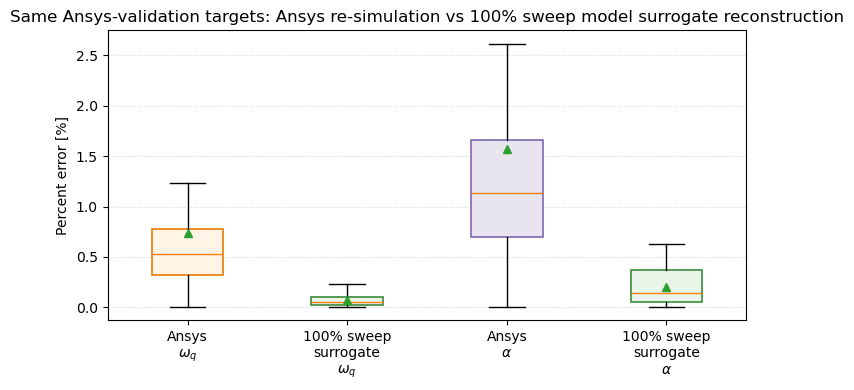

In [17]:
# Plot direct comparison on the same Ansys-successful samples.
# This does not replace Ansys validation; it shows the surrogate-only error of the retrained
# 100% sweep model on the same target Hamiltonians used for the Ansys boxplot.

if all_detail and not ansys_result_df.empty:
    detail_df = pd.concat(all_detail, ignore_index=True)
    detail_path = OUTPUT_DIR / "all_seed_comparison_with_existing_ansys_results.csv"
    detail_df.to_csv(detail_path, index=False)
    print(f"Wrote {detail_path}")

    overlap = detail_df.dropna(subset=["ansys_frequency_pct_error", "ansys_anharmonicity_pct_error"])
    first_seed = overlap[overlap["seed"].eq(SEEDS_TO_RUN[0])]
    box_data = [
        first_seed["ansys_frequency_pct_error"].to_numpy(),
        overlap["surrogate_frequency_pct_error"].to_numpy(),
        first_seed["ansys_anharmonicity_pct_error"].to_numpy(),
        overlap["surrogate_anharmonicity_pct_error"].to_numpy(),
    ]
    labels = [
        "Ansys\n$\\omega_q$",
        "100% sweep\nsurrogate\n$\\omega_q$",
        "Ansys\n$\\alpha$",
        "100% sweep\nsurrogate\n$\\alpha$",
    ]

    fig, ax = plt.subplots(figsize=(7.2, 4.0))
    bp = ax.boxplot(box_data, labels=labels, patch_artist=True, showmeans=True, showfliers=False)
    colors = ["#FFF4E6", "#E8F5E8", "#E8E4F0", "#E8F5E8"]
    edges = ["#E87A00", "#3D8B3D", "#7B68AE", "#3D8B3D"]
    for patch, face, edge in zip(bp["boxes"], colors, edges):
        patch.set_facecolor(face)
        patch.set_edgecolor(edge)
        patch.set_linewidth(1.2)
    ax.set_ylabel("Percent error [%]")
    ax.set_title("Same Ansys-validation targets: Ansys re-simulation vs 100% sweep model surrogate reconstruction")
    ax.grid(axis="y", linestyle=":", alpha=0.5)
    fig.tight_layout()

    png_path = OUTPUT_DIR / "boxplot_ansys_vs_100pct_sweep_surrogate_same_targets.png"
    pdf_path = OUTPUT_DIR / "boxplot_ansys_vs_100pct_sweep_surrogate_same_targets.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Wrote {png_path}")
    print(f"Wrote {pdf_path}")
else:
    print("No detail data or Ansys overlap available yet. Run the training/evaluation cell first.")


## How To Read The Outputs

For new Ansys simulations, use the clean per-seed CSVs named `seed*_ansys_input_geometry_predictions.csv`. These are in the same 10-column format as the original `Hamiltonian-based-inverse+surrogate_MLP_results.csv`, but the `pred_*` columns come from the saved 100% sweep model. They do not include old Ansys prediction columns.

The key summary comparison is in `results/validation/data_amount_100pct_on_ansys_targets/summary_100pct_sweep_model_on_ansys_targets.csv`.

Rows named `saved_100pct_sweep_model_ansys_100_targets_surrogate_only` answer: “If I feed the 100 Ansys-target Hamiltonians through the saved 100% sweep model from `ml_32` and then through the frozen surrogate, how close is the surrogate reconstruction to the target?”

Files named `seed*_comparison_with_existing_ansys_results.csv` are diagnostic only. They merge the new model predictions with the old Ansys re-simulation results so the previous boxplot can be compared, but they should not be used as fresh Ansys input.

If this notebook raises a missing-model error, run `ml_32_corner_far_to_near.ipynb` first so the `fraction_100pct_seed*_combined.keras` files are created.
